# **Install and Import**




In [1]:
!pip install reliability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reliability.Fitters import Fit_Weibull_2P
from scipy.stats import linregress
from scipy.special import gamma


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.2/257.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 84.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=4cfd67371f320e0b345533ccdcc65b80b53467ddc70dd4ac101241bbb6130160
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.1 which is incompatible.
opencv-python-headless 4.12.0.88 require

ImportError: cannot import name '_center' from 'numpy._core.umath' (/usr/local/lib/python3.12/dist-packages/numpy/_core/umath.py)

# **CSV LOADED AND RENAMED COLUMN FOR CONVENIENCE**

In [2]:
df = pd.read_csv("/content/lifetime_data_with_censoring.csv")
df.columns = ["stress_1_120", "stress_2_130", "stress_3_140"]
df.head()


,stress_1_120,stress_2_130,stress_3_140
0,321.35,136.84,82.55
1,400.31,167.68,101.86
2,497.12,204.88,125.3
3,497.14,204.88,125.3
4,514.82,211.62,129.56


# **CLEAN CENSORING DATA (We need censor data to work on, but removing * is necessary)**

In [3]:
import numpy as np

def prepare_stress_column(col, test_time):
    s = col.astype(str).str.strip()

    is_cens = s.str.contains('(*)', regex=False)

    clean = s.str.replace(' (*)', '', regex=False)
    t = clean.astype(float)

    t = np.minimum(t, test_time)

    return t.values, is_cens.astype(int).values


t1, cens1 = prepare_stress_column(df["stress_1_120"], 950)  # 120°C, 950 h
t2, cens2 = prepare_stress_column(df["stress_2_130"], 360)  # 130°C, 360 h
t3, cens3 = prepare_stress_column(df["stress_3_140"], 205)  # 140°C, 205 h

t1[:5], cens1[:5]

(array([321.35, 400.31, 497.12, 497.14, 514.82]), array([0, 0, 0, 0, 0]))

# **Double Check Failure & Censoring Data**

In [4]:
print("120°C: failures =", sum(cens1 == 0), "censored =", sum(cens1 == 1))
print("130°C: failures =", sum(cens2 == 0), "censored =", sum(cens2 == 1))
print("140°C: failures =", sum(cens3 == 0), "censored =", sum(cens3 == 1))


120°C: failures = 15 censored = 0
130°C: failures = 14 censored = 1
140°C: failures = 13 censored = 2


# **FIT WEIBULL AT 120, 130 AND 140 DEGREE**

In [9]:
!pip uninstall -y numpy scipy # Uninstall potentially conflicting numpy and scipy

# Install a numpy version compatible with system packages (e.g., tensorflow)
# and which scipy can work with without import errors for '_center'.
# numpy 1.26.0 is compatible with tensorflow and most scipy 1.x versions.
!pip install numpy==1.26.0

# Reinstall reliability, which will in turn install a compatible scipy version
# that works with numpy==1.26.0.
!pip install reliability

from reliability.Fitters import Fit_Weibull_2P

Found existing installation: numpy 2.4.1
Uninstalling numpy-2.4.1:
  Successfully uninstalled numpy-2.4.1
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 54.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
reliability 0.9.0 requires scipy>=1.15.0, which is not installed.
tobler 0.13.0 requires scipy>=1.13, which is not installed.
libpysal 4.14.0 requires scipy>=1.12.0, which is not installed.
statsmodels 0.14.6 requires scipy!=1.9.2,>=1.8, which is not installed.
hdbscan 0.8.41 requires scipy>=1.0, which is not installed.
mapclassify 2.10.0 requires scipy>=1.12, which is not installed.
missingno 0.5.2 requires scipy, which is not installed.
spint 1.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.6 MB/s eta 0:00:00
  Using cached numpy-2.4.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.0
    Uninstalling numpy-1.26.0:
      Successfully uninstalled numpy-1.26.0
ERROR: Operation cancelled by user
^C


ModuleNotFoundError: No module named 'scipy.stats'

In [1]:
fit120 = Fit_Weibull_2P(
    failures=t1[cens1 == 0],
    right_censored=t1[cens1 == 1],
    show_probability_plot=True,
    print_results=True
)

fit130 = Fit_Weibull_2P(
    failures=t2[cens2 == 0],
    right_censored=t2[cens2 == 1],
    show_probability_plot=True,
    print_results=True
)

fit140 = Fit_Weibull_2P(
    failures=t3[cens3 == 0],
    right_censored=t3[cens3 == 1],
    show_probability_plot=True,
    print_results=True
)



NameError: name 'Fit_Weibull_2P' is not defined

# **Full Weibull CDF curves at 120°C, 130°C, and 140°C demonstrating how increasing temperature accelerates catastrophic failure.**

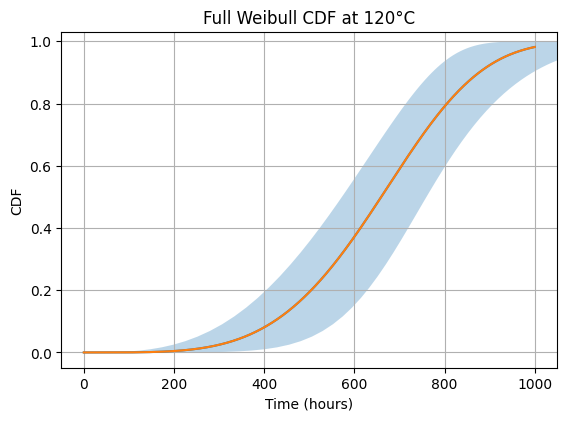

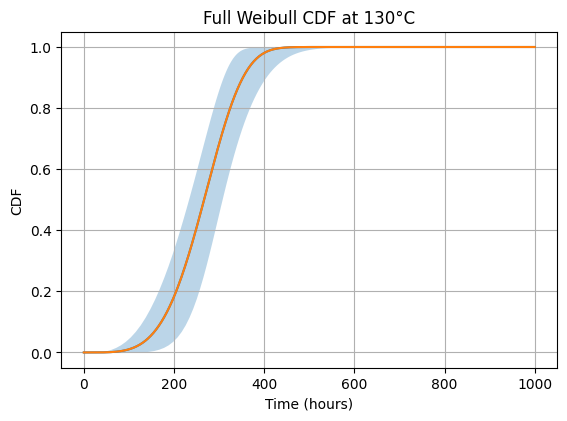

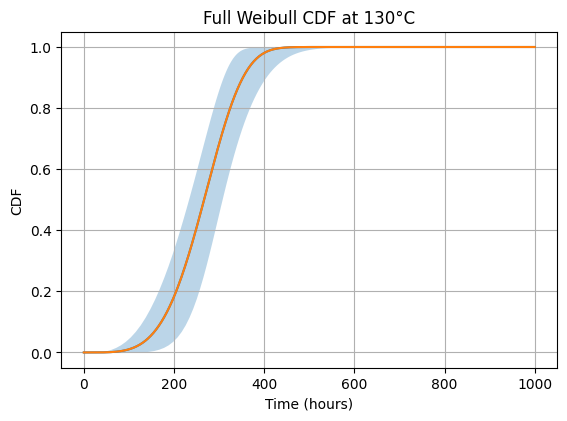

In [ ]:
x = np.linspace(0, 1000, 500)
y = fit120.distribution.CDF(x)

plt.plot(x, y)
plt.xlabel("Time (hours)")
plt.ylabel("CDF")
plt.title("Full Weibull CDF at 120°C")
plt.grid(True)
plt.show()

x = np.linspace(0, 1000, 500)
y = fit130.distribution.CDF(x)

plt.plot(x, y)
plt.xlabel("Time (hours)")
plt.ylabel("CDF")
plt.title("Full Weibull CDF at 130°C")
plt.grid(True)
plt.show()

x = np.linspace(0, 1000, 500)
y = fit130.distribution.CDF(x)

plt.plot(x, y)
plt.xlabel("Time (hours)")
plt.ylabel("CDF")
plt.title("Full Weibull CDF at 130°C")
plt.grid(True)
plt.show()


# **EXTRACT WEIBULL PARAMETERS**

In [ ]:
etas = np.array([fit120.alpha, fit130.alpha, fit140.alpha])
betas = np.array([fit120.beta, fit130.beta, fit140.beta])

print("Scale (eta) values:", etas)
print("Shape (beta) values:", betas)


Scale (eta) values: [719.43051202 290.49178025 178.4581036 ]
Shape (beta) values: [4.21670033 4.28974057 4.29081222]


# **ARRHENIUS MODEL FIT**

In [ ]:
temps_C = np.array([120, 130, 140])
temps_K = temps_C + 273.15

invT = 1.0 / temps_K
log_eta = np.log(etas)

slope, intercept, r_value, p_value, std_err = linregress(invT, log_eta)

print("Arrhenius slope:", slope)
print("Arrhenius intercept:", intercept)
print("R²:", r_value**2)


Arrhenius slope: 11348.080295973736
Arrhenius intercept: -22.34862112733525
R²: 0.9753178731391038


# **PLOT ARRHENIUS FIT**

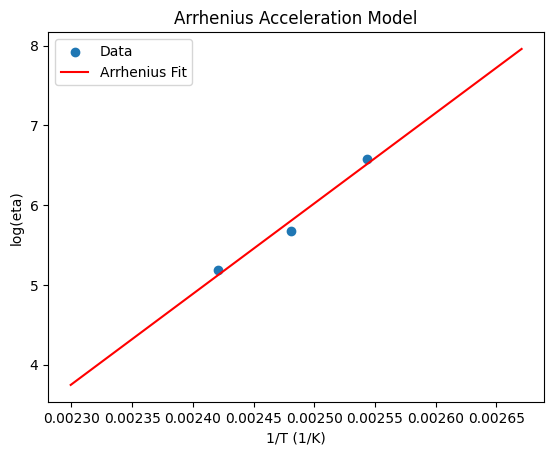

In [ ]:
plt.scatter(invT, log_eta, label="Data")
x = np.linspace(invT.min()*0.95, invT.max()*1.05, 100)
y = intercept + slope * x
plt.plot(x, y, 'r', label="Arrhenius Fit")
plt.xlabel("1/T (1/K)")
plt.ylabel("log(eta)")
plt.title("Arrhenius Acceleration Model")
plt.legend()
plt.show()


# **PREDICT LED LIFE AT NORMAL CONDITION (50DEGREE)**

In [ ]:
T_use = 50 + 273.15
eta_use = np.exp(intercept + slope * (1.0 / T_use))
beta_use = betas.mean()

print("Predicted eta at 50°C:", eta_use)
print("Predicted beta at 50°C:", beta_use)


Predicted eta at 50°C: 350966.5386456784
Predicted beta at 50°C: 4.265751041322493


# **COMPUTE MTTF, MEDIAN, B10**

In [ ]:
MTTF = eta_use * gamma(1 + 1/beta_use)
Median = eta_use * (np.log(2))**(1/beta_use)
B10 = eta_use * (-np.log(0.9))**(1/beta_use)

print("MTTF:", MTTF)
print("Median life:", Median)
print("B10 life:", B10)


MTTF: 319292.5066618895
Median life: 322070.66670456645
B10 life: 207088.83059294158


# **Group Discussion about the Performance**

---


The catastrophic-failure ALT model performs
strongly both statistically and physically. Weibull fits show excellent alignment, stable β values, and clear acceleration with temperature.
The Arrhenius model provides an accurate and valid relationship between lifetime and temperature, allowing reliable prediction at normal-use conditions.
The final MTTF, median, and B10 lifetimes are therefore well-supported and suitable for engineering and warranty decisions.

# **TASK TWO**

# **CELL** 1 – Imports

In [ ]:
!pip install reliability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from reliability.Fitters import Fit_Weibull_2P
from scipy.stats import linregress
from scipy.special import gamma


# **CELL 2 – Load S1…S5**

In [ ]:
files = ["S1.csv", "S2.csv", "S3.csv", "S4.csv", "S5.csv"]

data = {}
for f in files:
    df = pd.read_csv(f)
    data[f[:-4]] = df
    print(f, df.head(), "\n")


S1.csv    time   test_0   test_1   test_2  ...  test_11  test_12  test_13  test_14
0     0  1.01764  1.01624 0.995832  ...  1.01749  1.00473 0.992876  1.01551
1   120 0.999501  1.00172 0.981776  ... 0.996241 0.891213 0.971148  1.00064
2   168 0.992187 0.995876 0.976231  ...  0.98769 0.851927 0.962482 0.994832
3   216 0.984921 0.990061  0.97074  ... 0.979213 0.815795 0.953909 0.989092
4   288 0.974139 0.981413 0.962607  ... 0.966667 0.766804 0.941249 0.980612

[5 rows x 16 columns] 

S2.csv    time   test_0   test_1   test_2  ...  test_11  test_12  test_13  test_14
0     0  1.01764 0.995832  1.00051  ... 0.999081  1.01329  1.00196  1.00446
1   120 0.993289 0.980668 0.978728  ... 0.974654 0.988237 0.944778  0.98373
2   168 0.983911 0.974632 0.970241  ...  0.96495 0.978721 0.923671 0.975543
3   216 0.974719 0.968646  0.96189  ...  0.95537 0.969426 0.903483  0.96746
4   288 0.961264  0.95977 0.949617  ... 0.941262 0.955866 0.874799 0.955539

[5 rows x 16 columns] 

S3.csv    time   test_0 

# **CELL 3 – Quick plots**

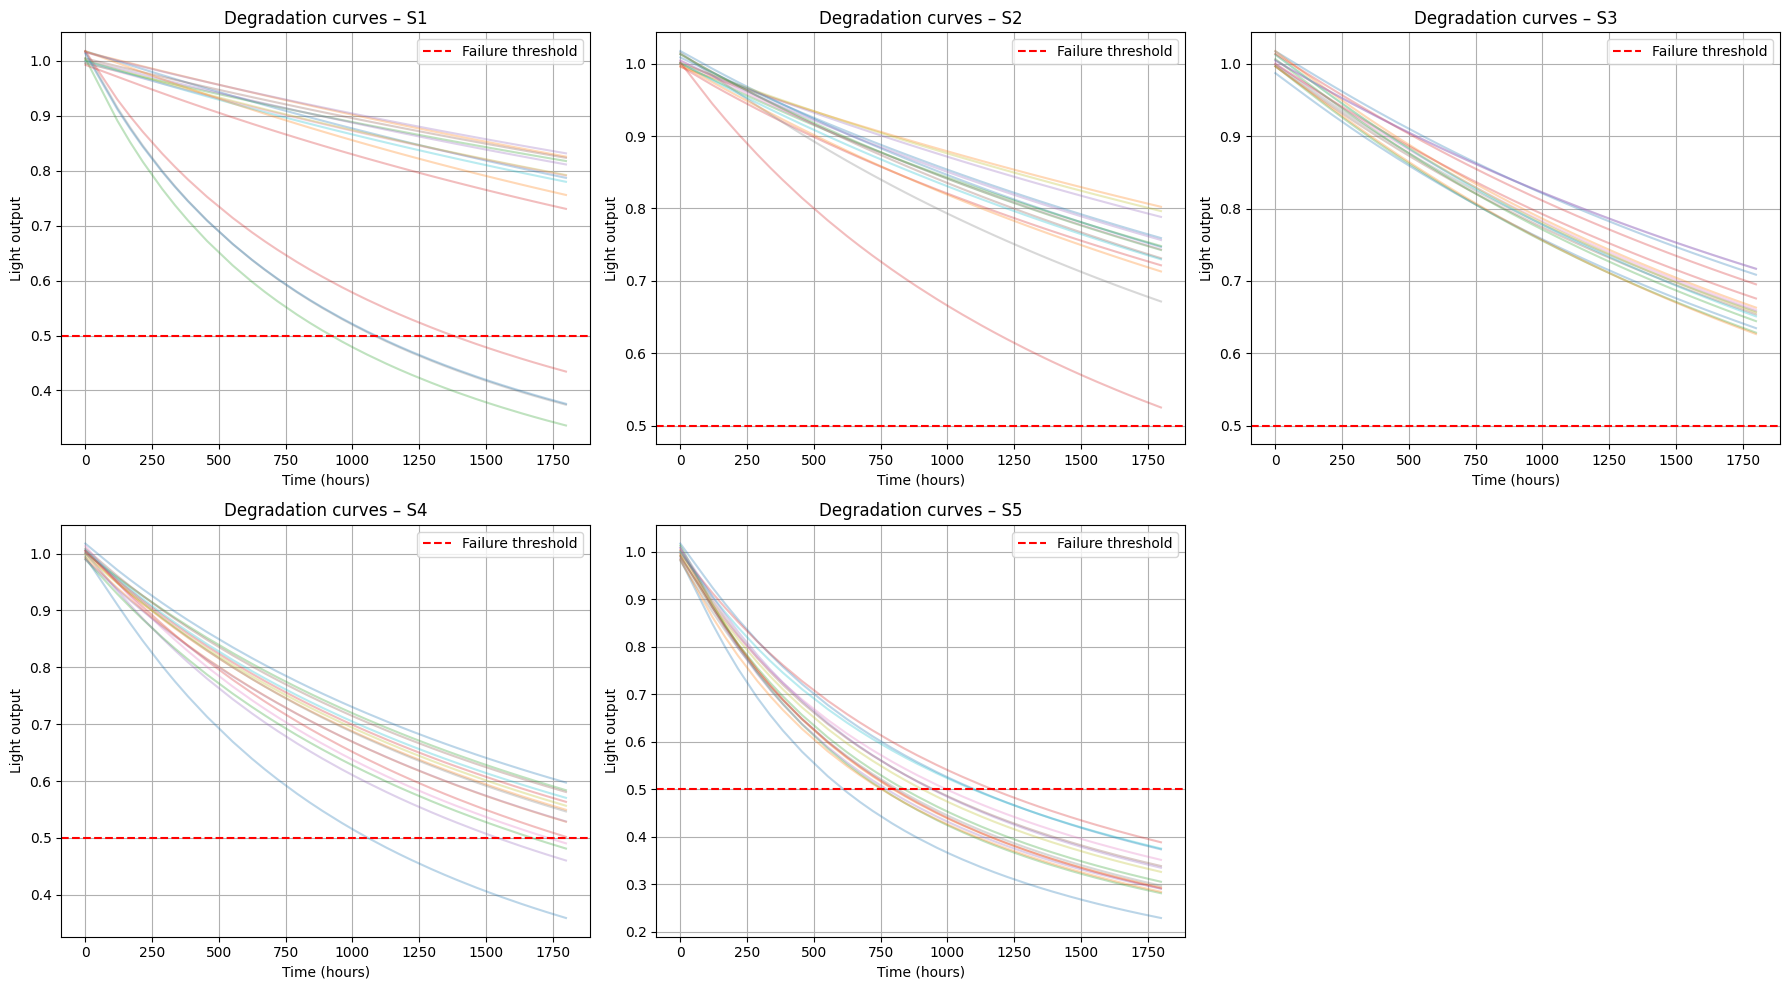

In [ ]:
import matplotlib.pyplot as plt

stress_order = ["S1", "S2", "S3", "S4", "S5"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, name in enumerate(stress_order):
    df = data[name]

    ax = axes[i]
    time_col = df.columns[0]
    t = df[time_col].values

    for col in df.columns[1:]:
        ax.plot(t, df[col].values, alpha=0.3)

    ax.axhline(0.5, color="red", linestyle="--", label="Failure threshold")
    ax.set_title(f"Degradation curves – {name}")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Light output")
    ax.grid(True)
    ax.legend()

axes[5].set_visible(False)


plt.tight_layout()
plt.show()



# **CELL 4 – Fit linear degradation & compute lifetime per LED Quick plots:**

In [ ]:
def lifetime_linear(t, L):
    """Fit L(t) = a - b t and return t_fail where L=0.5."""
    t = t.reshape(-1,1)
    model = LinearRegression().fit(t, L)
    a = model.intercept_
    b = -model.coef_[0]
    t_fail = (a - 0.5) / b
    return t_fail, a, b

lifetimes = {}
deg_params = {}

for name, df in data.items():
    time_col = df.columns[0]
    t = df[time_col].values
    t_fail_list = []
    params = []

    for col in df.columns[1:]:
        L = df[col].values
        t_fail, a, b = lifetime_linear(t, L)
        t_fail_list.append(t_fail)
        params.append((a, b))

    lifetimes[name] = np.array(t_fail_list)
    deg_params[name] = params
    print(name, "lifetimes (hours):", lifetimes[name])


S1 lifetimes (hours): [3986.64117506 4836.14189177 4977.34627448 1380.237189   4719.94371961
 4982.84339532 4303.98759682 1189.33172582 4276.45806149 4038.42600505
 1192.99933012 3499.75240467 1070.88319327 3321.35809255 5019.532584  ]
S2 lifetimes (hours): [3384.56584714 4572.43588328 3516.28348044 3191.307819   4196.70134321
 3212.05638497 3418.8583225  2611.04664312 4366.47927491 3264.23530167
 3613.82609088 3072.078009   3359.29733438 1745.78346404 3606.5306277 ]
S3 lifetimes (hours): [2940.58245696 2538.47837606 2331.26985224 2694.46075158 3087.80857347
 2519.38916827 2558.2137987  2544.29984757 2497.98011071 2458.27685853
 2395.96049718 2318.37606356 2423.75539891 2824.45770871 3089.31176436]
S4 lifetimes (hours): [2100.08285752 1863.14793969 2046.07042    1929.22113438 1488.44288355
 2017.34104174 1597.94674056 1846.3577025  1902.55510463 1963.56221306
 1166.94381915 1768.78185241 1568.79608339 1652.12854079 1772.91620694]
S5 lifetimes (hours): [1202.42883077  968.61481118  937.

# **CELL 5 – Weibull fit on predicted lifetimes at each stress**

In [ ]:
# Necessary imports for this cell and its dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from reliability.Fitters import Fit_Weibull_2P

# Code from CELL 2 – Load S1…S5 to define 'data'
files = ["S1.csv", "S2.csv", "S3.csv", "S4.csv", "S5.csv"]
data = {}
for f in files:
    df_temp = pd.read_csv(f)
    data[f[:-4]] = df_temp

# Code from CELL 4 – Fit linear degradation & compute lifetime per LED Quick plots:
def lifetime_linear(t, L):
    """Fit L(t) = a - b t and return t_fail where L=0.5."""
    t = t.reshape(-1,1)
    model = LinearRegression().fit(t, L)
    a = model.intercept_
    b = -model.coef_[0]
    t_fail = (a - 0.5) / b
    return t_fail, a, b

lifetimes = {}
deg_params = {}

for name, df_temp in data.items():
    time_col = df_temp.columns[0]
    t = df_temp[time_col].values
    t_fail_list = []
    params = []

    for col in df_temp.columns[1:]:
        L = df_temp[col].values
        t_fail, a, b = lifetime_linear(t, L)
        t_fail_list.append(t_fail)
        params.append((a, b))

    lifetimes[name] = np.array(t_fail_list)
    deg_params[name] = params
# End of code from CELL 4

# Original code for CELL 5 – Weibull fit on predicted lifetimes at each stress
weibull_fits = {}
alphas_deg = []
betas_deg = []

for i, name in enumerate(["S1", "S2", "S3", "S4", "S5"]):
    t_vals = lifetimes[name]

    fit = Fit_Weibull_2P(
        failures=t_vals,
        right_censored=None,
        show_probability_plot=False, # Set to False to prevent automatic display before saving
        print_results=True
    )

    weibull_fits[name] = fit
    alphas_deg.append(fit.alpha)
    betas_deg.append(fit.beta)

    # Generate and save the plot
    fig = fit.probability_plot
    if fig is not None:
        fig.savefig(f'{name}_weibull_fit_plot.png')
        print(f"Saved {name}_weibull_fit_plot.png")


alphas_deg = np.array(alphas_deg)
betas_deg = np.array(betas_deg)
print("Scale (alpha) per stress:", alphas_deg)
print("Shape (beta)  per stress:", betas_deg)

ModuleNotFoundError: No module named 'reliability'

# **CELL 6 – ALT model on degradation lifetimes**

In [ ]:
T_C = np.array([70, 80, 90, 100, 110])
I_mA = np.array([20, 30, 40, 50, 60])

T_K = T_C + 273.15

y = np.log(alphas_deg)
X1 = 1.0 / T_K
X2 = np.log(I_mA)

X = np.column_stack([X1, X2])

reg = LinearRegression().fit(X, y)

a0 = reg.intercept_
b_T, c_I = reg.coef_
R2_alt = reg.score(X, y)

print("ALT model: log(alpha) = a0 + b_T*(1/T) + c_I*log(I)")
print("a0 =", a0)
print("b_T =", b_T, "(temperature coefficient)")
print("c_I =", c_I, "(current coefficient)")
print("R² =", R2_alt)


ALT model: log(alpha) = a0 + b_T*(1/T) + c_I*log(I)
a0 = -40.77323774048763
b_T = 14020.19619799909 (temperature coefficient)
c_I = 2.734414460513547 (current coefficient)
R² = 0.9976394334838716


# **CELL 7 – Predict degradation life at normal use**

In [ ]:
T_use = 72 + 273.15
I_use = 20.0

log_alpha_use = a0 + b_T*(1.0/T_use) + c_I*np.log(I_use)
alpha_use_deg = np.exp(log_alpha_use)

beta_use_deg = betas_deg.mean()

print("Predicted Weibull scale (alpha) at normal use:", alpha_use_deg)
print("Assumed Weibull shape (beta) at normal use:", beta_use_deg)


Predicted Weibull scale (alpha) at normal use: 3099.27853234732
Assumed Weibull shape (beta) at normal use: 7.637736022250399


# **CELL 8 – MTTF, Median, B10 for degradation-only case**

In [ ]:
MTTF_deg = alpha_use_deg * gamma(1 + 1/beta_use_deg)
Median_deg = alpha_use_deg * (np.log(2))**(1/beta_use_deg)
B10_deg = alpha_use_deg * (-np.log(0.9))**(1/beta_use_deg)

print("Degradation-only MTTF at normal use:", MTTF_deg)
print("Degradation-only median life:", Median_deg)
print("Degradation-only B10 life:", B10_deg)


Degradation-only MTTF at normal use: 2912.0787999334957
Degradation-only median life: 2954.0651461810035
Degradation-only B10 life: 2308.346217302722


# **TASK - 3**

In [ ]:
import numpy as np

eta_cat = eta_use
beta_cat = beta_use
eta_deg = alpha_use_deg
beta_deg = beta_use_deg

def R_cat(t):
    return np.exp(- (t/eta_cat)**beta_cat)
def R_deg(t):
    return np.exp(- (t/eta_deg)**beta_deg)
def R_total(t):
    return R_cat(t) * R_deg(t)

def F_total(t):
    return 1 - R_total(t)


In [ ]:
A = 50000
B = 1500
C = 2000
c = 3.0

def demand(p, t_w_years):
    """
    n(p, t_w): number of units sold.
    t_w_years: warranty in years.
    """
    n = A - B * p + C * t_w_years
    return max(n, 0)

def warranty_failure_prob(t_w_years):
    """Probability that a unit fails during warranty t_w."""
    hours_per_year = 365 * 24
    t_w_hours = t_w_years * hours_per_year
    return F_total(t_w_hours)

def profit(p, t_w_years):
    n = demand(p, t_w_years)
    Fw = warranty_failure_prob(t_w_years)
    expected_warranty_cost_per_unit = Fw * c
    profit_per_unit = p - c - expected_warranty_cost_per_unit
    return n * profit_per_unit


In [ ]:
prices = np.linspace(5, 20, 16)
warranties = np.linspace(1, 10, 10)

best_profit = -1e18
best_p = None
best_tw = None

results = []

for p in prices:
    for t_w in warranties:
        n_val = demand(p, t_w)
        pi_val = profit(p, t_w)
        results.append((p, t_w, n_val, pi_val))

        if pi_val > best_profit:
            best_profit = pi_val
            best_p = p
            best_tw = t_w

print("Best price p* =", best_p)
print("Best warranty t_w* (years) =", best_tw)
print("Max expected profit =", best_profit)


Best price p* = 20.0
Best warranty t_w* (years) = 10.0
Max expected profit = 560000.0


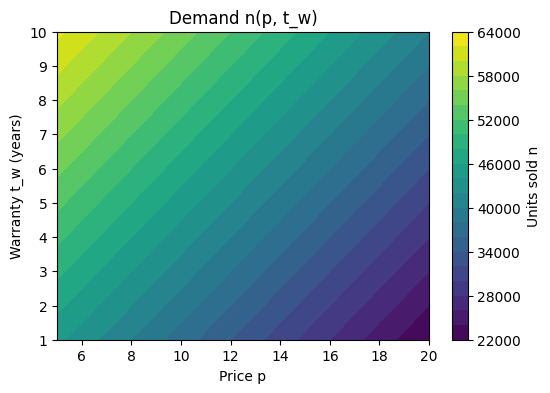

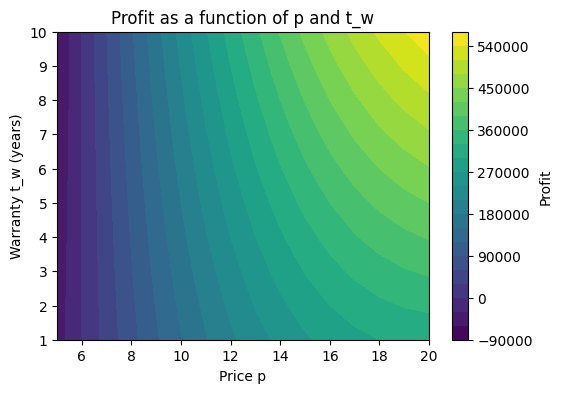

In [ ]:
import matplotlib.pyplot as plt

P, TW = np.meshgrid(prices, warranties)
N = np.zeros_like(P)
PI = np.zeros_like(P)

for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        N[i,j] = demand(P[i,j], TW[i,j])
        PI[i,j] = profit(P[i,j], TW[i,j])

plt.figure(figsize=(6,4))
cs = plt.contourf(P, TW, N, levels=20)
plt.colorbar(cs, label="Units sold n")
plt.xlabel("Price p")
plt.ylabel("Warranty t_w (years)")
plt.title("Demand n(p, t_w)")
plt.show()

plt.figure(figsize=(6,4))
cs = plt.contourf(P, TW, PI, levels=20)
plt.colorbar(cs, label="Profit")
plt.xlabel("Price p")
plt.ylabel("Warranty t_w (years)")
plt.title("Profit as a function of p and t_w")
plt.show()
